In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

In [2]:
df = pd.read_csv("/Users/ruch/Desktop/ML-Engineer/Core/Data Science/Sleep Health and Lifestyle Prediction/Sleep_health_and_lifestyle_dataset.csv")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [3]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
df.shape

(374, 13)

In [6]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [7]:
df.value_counts()

Person ID  Gender  Age  Occupation            Sleep Duration  Quality of Sleep  Physical Activity Level  Stress Level  BMI Category  Blood Pressure  Heart Rate  Daily Steps  Sleep Disorder
4          Male    28   Sales Representative  5.9             4                 30                       8             Obese         140/90          85          3000         Sleep Apnea       1
290        Female  50   Nurse                 6.1             6                 90                       8             Overweight    140/95          75          10000        Sleep Apnea       1
283        Female  50   Nurse                 6.0             6                 90                       8             Overweight    140/95          75          10000        Sleep Apnea       1
284        Female  50   Nurse                 6.0             6                 90                       8             Overweight    140/95          75          10000        Sleep Apnea       1
285        Female  50   Nurse      

In [8]:
df["Sleep Disorder"].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

In [9]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [10]:
219 + 78 + 77

374

In [11]:
df["Blood Pressure"]

0      126/83
1      125/80
2      125/80
3      140/90
4      140/90
        ...  
369    140/95
370    140/95
371    140/95
372    140/95
373    140/95
Name: Blood Pressure, Length: 374, dtype: object

In [12]:
df["Blood Pressure"].str.isnumeric().sum()

0

In [13]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True) # expand=True Listeyi genişlet, her elemanı ayrı sütuna koy.
df['Systolic'] = df['Systolic'].astype(float)
df['Diastolic'] = df['Diastolic'].astype(float)
df = df.drop(columns=['Blood Pressure'])

In [14]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126.0,83.0
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125.0,80.0
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125.0,80.0
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
 12  Systolic                 374 non-null    float64
 13  Diastolic                374 non-null    float64
dtypes: float64(3), int64(7), o

In [16]:
df.drop("Person ID", inplace=True, axis=1)

In [17]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126.0,83.0
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125.0,80.0
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125.0,80.0
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0


In [18]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('Healthy')

In [19]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
Healthy        219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [20]:
numeric_features = df.select_dtypes(include=[np.number])
numeric_features

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,Diastolic
0,27,6.1,6,42,6,77,4200,126.0,83.0
1,28,6.2,6,60,8,75,10000,125.0,80.0
2,28,6.2,6,60,8,75,10000,125.0,80.0
3,28,5.9,4,30,8,85,3000,140.0,90.0
4,28,5.9,4,30,8,85,3000,140.0,90.0
...,...,...,...,...,...,...,...,...,...
369,59,8.1,9,75,3,68,7000,140.0,95.0
370,59,8.0,9,75,3,68,7000,140.0,95.0
371,59,8.1,9,75,3,68,7000,140.0,95.0
372,59,8.1,9,75,3,68,7000,140.0,95.0


In [21]:
categorical_features = df.select_dtypes(include=[object])
categorical_features

,Gender,Occupation,BMI Category,Sleep Disorder
0,Male,Software Engineer,Overweight,Healthy
1,Male,Doctor,Normal,Healthy
2,Male,Doctor,Normal,Healthy
3,Male,Sales Representative,Obese,Sleep Apnea
4,Male,Sales Representative,Obese,Sleep Apnea
...,...,...,...,...
369,Female,Nurse,Overweight,Sleep Apnea
370,Female,Nurse,Overweight,Sleep Apnea
371,Female,Nurse,Overweight,Sleep Apnea
372,Female,Nurse,Overweight,Sleep Apnea


In [22]:
categorical_features_list = categorical_features.columns.tolist()
categorical_features_list

['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

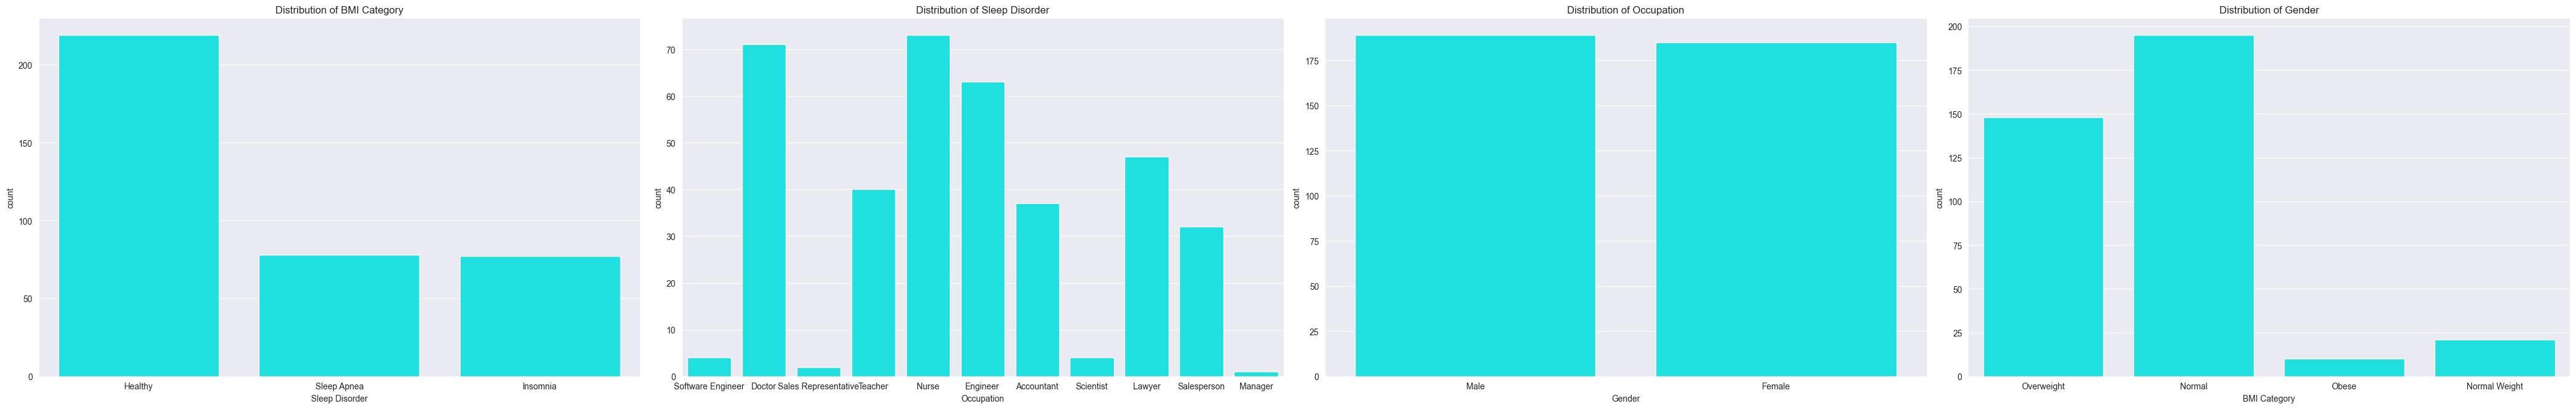

In [23]:
plt.figure(figsize=(42,32))

category = ['Sleep Disorder', 'Occupation', 'Gender', 'BMI Category']

for i in range(0, len(category)):
    plt.subplot(5, 4, i+1)
    sns.countplot(x=df[category[i]], color='cyan')
    plt.xlabel(category[i])
    plt.title(f'Distribution of {category[i-1]}')
    plt.tight_layout()

plt.show()

In [24]:
numeric_features_list = numeric_features.columns.tolist()
numeric_features_list

['Age',
 'Sleep Duration',
 'Quality of Sleep',
 'Physical Activity Level',
 'Stress Level',
 'Heart Rate',
 'Daily Steps',
 'Systolic',
 'Diastolic']

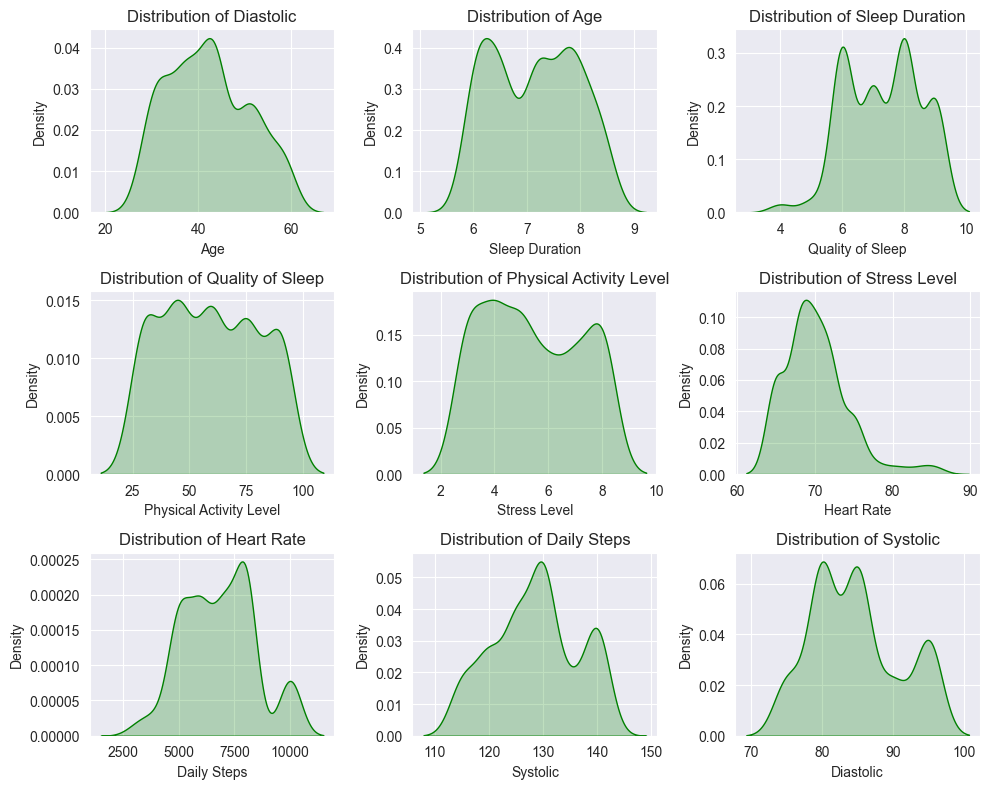

In [25]:
plt.figure(figsize=(10,8))

for i in range(0, len(numeric_features_list)):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(x=df[numeric_features_list[i]], color='green', fill=True)
    plt.xlabel(numeric_features_list[i])
    plt.title(f'Distribution of {numeric_features_list[i-1]}')
    plt.tight_layout()

plt.show()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
dtypes: float64(3), int64(6), object(4)
memory usage: 38.1+ KB


In [27]:
df.shape

(374, 13)

In [28]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,Healthy,126.0,83.0
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125.0,80.0
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125.0,80.0
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
dtypes: float64(3), int64(6), object(4)
memory usage: 38.1+ KB


In [30]:
label_encoder = LabelEncoder()

In [31]:
df["Gender"]

0        Male
1        Male
2        Male
3        Male
4        Male
        ...  
369    Female
370    Female
371    Female
372    Female
373    Female
Name: Gender, Length: 374, dtype: object

In [32]:
df["Gender"] = label_encoder.fit_transform(df["Gender"])

In [33]:
df["Gender"]

0      1
1      1
2      1
3      1
4      1
      ..
369    0
370    0
371    0
372    0
373    0
Name: Gender, Length: 374, dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    int64  
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
dtypes: float64(3), int64(7), object(3)
memory usage: 38.1+ KB


In [41]:
df["Occupation"].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [42]:
encoder = LabelEncoder()
df['Occupation'] = encoder.fit_transform(df['Occupation'])

In [43]:
df["Occupation"]

0      9
1      1
2      1
3      6
4      6
      ..
369    5
370    5
371    5
372    5
373    5
Name: Occupation, Length: 374, dtype: int64

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    int64  
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    int64  
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
dtypes: float64(3), int64(8), object(2)
memory usage: 38.1+ KB


In [45]:
df["BMI Category"].unique()

array(['Overweight', 'Normal', 'Obese', 'Normal Weight'], dtype=object)

In [46]:
df["BMI Category"] = df["BMI Category"].replace("Normal", "Underweight")

In [47]:
df["BMI Category"].unique()

array(['Overweight', 'Underweight', 'Obese', 'Normal Weight'],
      dtype=object)